# PRÁCTICA BACKTESTING AVANZADO

##### Realizado por Mateo Santos

In [48]:
# Importamos las librerías
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns
import scipy
import pyarrow
import pyarrow.parquet as pq
import time

# Fijamos la semilla
np.random.seed(42)

In [2]:
# Definición de variables globales
capital = 250000
#START_DATE = '2015-01-01'
START_DATE = '2014-01-01'
END_DATE = '2026-01-31'
NUM_ACTIVOS = 20
capital_por_activo = capital/NUM_ACTIVOS

## Notebook 6: Test de Monte Carlo (Monos)

Para configurar el simulador de Monte Carlo, es necesario que fijemos de antemano las variables:

- **`mascara`**: Mascara booleana que determina para cada activo las fechas en las que se puede invertir
- **`matriz_retornos_netos`**: Retornos mensuales porcentuales de cada activo

In [ ]:
#####################  OBTENEMOS LA MÁSCARA PARA SABER EN QUE MESES Y ACTIVOS SE PUEDE INVERTIR (ES FIJA)

matriz_activos = activos_aptos.loc[fechas_reales].fillna(False)
matriz_activos = matriz_activos[precios_compra.columns].values
mascara = matriz_activos*matriz_sp500.loc[fechas_reales].fillna(False)[precios_compra.columns].values.astype(bool)

In [ ]:
###############################   CALCULAMOS LA MATRIZ DE RETORNOS (ES FIJA)

precios_c = precios_compra.values
precios_v = precios_venta.shift(-1).values # El shift se hace una sola vez aquí
com = 0.0023

matriz_retornos_netos = (precios_v * (1 - com)) / (precios_c * (1 + com)) - 1
matriz_retornos_netos = np.nan_to_num(matriz_retornos_netos) # Limpiamos NaNs

Definimos la clase **`SimuladorMonos`** cuyo constructor necesita de las variables **`mascara`** y **`matriz_retornos_netos`** definidas anteriormente, así como el número de simulaciones a realizar y la cantidad a invertir por activo.

La función **`run()`** es la encargada de realizar las simulaciones. **Se realiza de forma vectorizada por lotes**. Mi ordenador no tiene la suficiente capacidad como para hacer el cálculo vectorial completo en una sola operación.

La **salida son los rentabilidades finales de cada una de las simulaciones**. No he podido guardar las rentabilidades mensuales de cada simulación porque no tenía la suficiente memoria.

In [ ]:
class SimuladorMonos:
    def __init__(self, matriz_retornos, mascara, k=20, capital_por_activo=12500):
        """
        Inicializa el simulador con los datos y parámetros base.
        """
        self.matriz_retornos = matriz_retornos
        self.mascara = mascara
        self.k = k
        self.capital_por_activo = capital_por_activo
        
        self.n_meses, self.n_activos = mascara.shape
        
        # Pre-procesamiento: Identificar qué activos son aptos cada mes
        self.activos_aptos_por_mes = [np.where(self.mascara[m])[0] for m in range(self.n_meses)]
        
        # Espacio para resultados
        self.ganancias_netas = None

    def run(self, n_total_simulaciones=25000000, chunk_size=200000):
        """
        Ejecuta la simulación masiva utilizando procesamiento por bloques (chunks).
        """
        self.ganancias_netas = np.zeros(n_total_simulaciones)
        
        print(f"Iniciando cálculo masivo...")
        start_time = time.time()

        for i in range(0, n_total_simulaciones, chunk_size):
            n_sim = min(chunk_size, n_total_simulaciones - i)
            ganancia_bloque = np.zeros(n_sim)
            
            # Bucle por mes (vectorizado para todas las sims del chunk)
            for m in range(self.n_meses):
                aptos = self.activos_aptos_por_mes[m]
                n_aptos = len(aptos)
                
                if n_aptos >= self.k:
                    # 1. Generar aleatorios para selección
                    rand_mes = np.random.random((n_sim, n_aptos))
                    
                    # 2. Selección de los k mejores índices (aleatorios)
                    idx_relativo = np.argpartition(rand_mes, -self.k, axis=1)[:, -self.k:]
                    
                    # 3. Obtener retornos reales
                    retornos_aptos = self.matriz_retornos[m, aptos]
                    retornos_elegidos = np.take_along_axis(retornos_aptos[None, :], idx_relativo, axis=1)
                    
                    # 4. Acumular ganancia monetaria
                    ganancia_bloque += retornos_elegidos.sum(axis=1) * self.capital_por_activo
            
            # Guardar bloque en el array principal
            self.ganancias_netas[i:i+n_sim] = ganancia_bloque
            
            # Feedback de progreso
            if i % 1000000 == 0:
                print('Simulación '+str(i))
        end_time = time.time()
        total_time = end_time - start_time
        print(f"Completado en {total_time/3600:.2f} horas")
        return self.ganancias_netas

Al llamar a la clase **`SimuladorMonos`** se ejecuta la función **`run()`** con los datos. En este caso, ha tardado en realizar todas las simulaciones unas **10 horas y media**. Por lo que cumple con la condición de ejecución en menos de 24 horas.

En la variable **`ganancias_netas_monos`** se almacena el excedente del capital inicial (rentabilidad) de cada una de las simulaciones. La salida en este caso, es un array de 25.000.000 posiciones.

In [56]:
# 1. Instanciar (puedes cambiar k o el capital aquí)
simulador = SimuladorMonos(matriz_retornos_netos, mascara, k=20, capital_por_activo=12500)

# 2. Ejecutar la simulación
ganancias_netas_monos = simulador.run(n_total_simulaciones=25000000, chunk_size=200000)

Iniciando cálculo masivo...
Simulación 0
Simulación 1000000
Simulación 2000000
Simulación 3000000
Simulación 4000000
Simulación 5000000
Simulación 6000000
Simulación 7000000
Simulación 8000000
Simulación 9000000
Simulación 10000000
Simulación 11000000
Simulación 12000000
Simulación 13000000
Simulación 14000000
Simulación 15000000
Simulación 16000000
Simulación 17000000
Simulación 18000000
Simulación 19000000
Simulación 20000000
Simulación 21000000
Simulación 22000000
Simulación 23000000
Simulación 24000000
Completado en 10.59 horas


Cargamos el resultado de la estrategia momentum que hemos obtenido para poder compararlo con los resultados de las simulaciones.

In [87]:
# Carga la curva de la estrategia
equity_estrategia = pd.read_csv('equity_estrategia.csv', index_col=0, parse_dates=True)

# Asegúrate de extraer los valores correctamente para el gráfico
valores_estrategia = equity_estrategia.iloc[:, 0] # Primera columna

Aquí calculamos el capital final de cada una de las simulaciones. Es decir, a cada uno de los excedentes obtenidos por las simulaciones, se le suma el capital inicial de $250.000$. Estos valores serán los que compararemos con el resultado de la estrategia.

In [88]:
# Obtenemos los valores finales para monos y momentum
capital_final_monos = 250000 + ganancias_netas_monos
capital_final_momentum = valores_estrategia.iloc[-1]

A partir de aquí se mostrarán gráficos y tablas que muestren los resultados de las simulaciones versus la estrategia momentum.

La primera muestra el **percentil de nuestra estrategia** comparado con los resultados finales de las 25.000.000 simulaciones. El resultado de la estrategia tiene un percentil muy elevado. Por lo que podría hacernos pensar que haya habido cierto sobreajuste o que las **penalizaciones por comisiones afectan mucho más** que en el caso de la estrategia momentum.

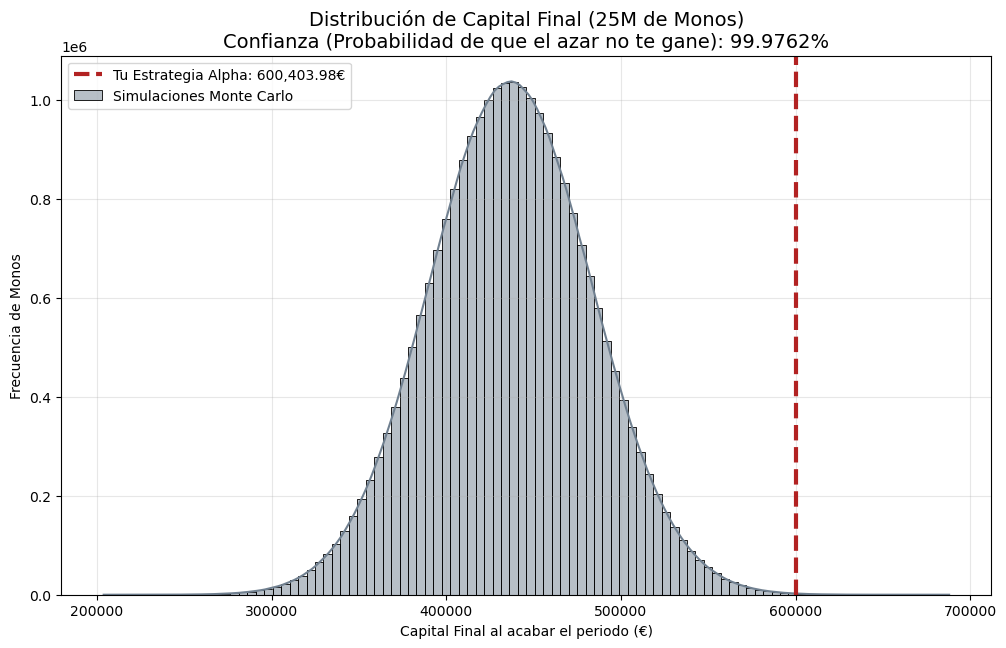

In [77]:
plt.figure(figsize=(12, 7))
sns.histplot(capital_final_monos, bins=100, kde=True, color='slategray', label='Simulaciones Monte Carlo')
plt.axvline(capital_final_momentum, color='firebrick', linestyle='--', linewidth=3, 
            label=f'Tu Estrategia Alpha: {capital_final_momentum:,.2f}€')

# Cálculo del p-value (Filtro de confianza)
p_value = np.mean(capital_final_monos > capital_final_momentum)

plt.title(f'Distribución de Capital Final (25M de Monos)\nConfianza (Probabilidad de que el azar no te gane): {(1-p_value)*100:.4f}%', fontsize=14)
plt.xlabel('Capital Final al acabar el periodo (€)')
plt.ylabel('Frecuencia de Monos')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

A continuación, se ejecuta una breve simulación de 200.000 monos para poder tener una muestra con la que comparar los resultados mensuales de la estrategia.

In [78]:
# EJECUTAR ESTO PARA OBTENER LA MUESTRA DEL GRÁFICO
n_monos_grafico = 200000
n_meses = mascara.shape[0]

# Matriz para guardar el retorno de cada mes de cada mono de la muestra
retornos_mensuales_muestra = np.zeros((n_monos_grafico, n_meses))

for m in range(n_meses):
    aptos = activos_aptos_por_mes[m]
    if len(aptos) >= k:
        rand_mes = np.random.random((n_monos_grafico, len(aptos)))
        idx_relativo = np.argpartition(rand_mes, -k, axis=1)[:, -k:]
        retornos_aptos = matriz_retornos_netos[m, aptos]
        
        # Guardamos la SUMA de los retornos de los k activos elegidos para ese mes
        # Esto es el % que gana el mono ese mes concreto
        retornos_mensuales_muestra[:, m] = np.take_along_axis(retornos_aptos[None, :], idx_relativo, axis=1).sum(axis=1)

El segundo gráfico muestra la **rentabilidad acumulada** de la estrategia momentum con respecto a las obtenidas por estas 200.000 simulaciones. Tal y como se puede apreciar, **la rentabilidad acumulada de la estrategia (marcada en rojo) es muy elevada**.

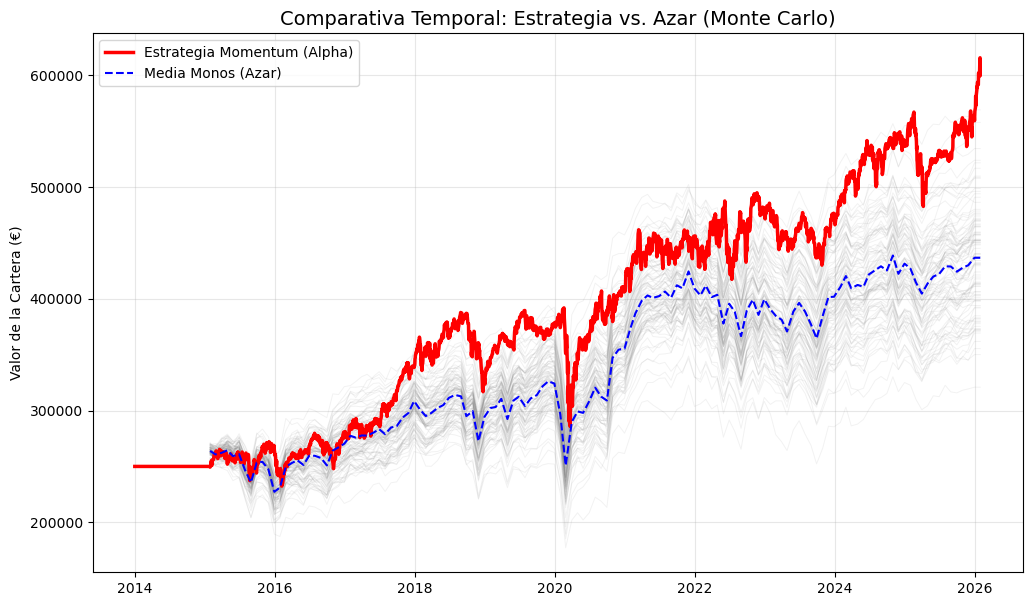

In [89]:
# Calcular las curvas de los monos de la muestra
# retornos_mensuales_muestra tiene forma (1000, 133)
curvas_monos = 250000 + (retornos_mensuales_muestra * 12500).cumsum(axis=1)

# Visualización Profesional
plt.figure(figsize=(12, 7))

# Graficar la nube de incertidumbre (Monos)
fechas_grafico = fechas_reales # Ajusta si falta alguna fecha de inicio
for i in range(100): # Solo 100 líneas para no saturar
    plt.plot(fechas_grafico, curvas_monos[i, :], color='gray', alpha=0.1, linewidth=0.7)

# Graficar tu estrategia
plt.plot(equity_estrategia.index, equity_estrategia.values, 
         color='red', linewidth=2.5, label='Estrategia Momentum (Alpha)')

# Graficar la media de los monos
plt.plot(fechas_grafico, curvas_monos.mean(axis=0), 
         color='blue', linestyle='--', label='Media Monos (Azar)')

plt.title('Comparativa Temporal: Estrategia vs. Azar (Monte Carlo)', fontsize=14)
plt.ylabel('Valor de la Cartera (€)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

A continuación, se calculan métricas de evaluación que nos permitan comparar el resultado de la estrategia comparado con el resultado de las 200.000 simulaciones. Las conclusiones son las siguientes:

- La **rentabilidad esperada es mucho mayor en el caso de la estrategia momentum**.
- La **estrategia momentum tiene un mayor riesgo por máximo drawdown que el promedio y mediana de las simulaciones**.

In [94]:
# --- Cálculo de métricas para la Estrategia ---
retornos_estrategia = equity_estrategia.pct_change().dropna()
# Retorno Anualizado (asumiendo rebalanceo mensual -> 12 meses)
retorno_anual_est = (1 + (equity_estrategia.iloc[-1] / 250000 - 1)) ** (12 / len(fechas_reales)) - 1

# Max Drawdown Estrategia
rolling_max = equity_estrategia.cummax()
drawdowns = (equity_estrategia - rolling_max) / rolling_max
max_dd_est = drawdowns.min()

# --- Cálculo de métricas para los 1.000 Monos ---
# Retorno Anualizado Monos
retorno_total_monos = curvas_monos[:, -1] / 250000 - 1
retorno_anual_monos = (1 + retorno_total_monos) ** (12 / len(fechas_reales)) - 1

# Max Drawdown Monos (vectorizado)
# curvas_monos tiene forma (1000, 133)
rolling_max_monos = np.maximum.accumulate(curvas_monos, axis=1)
drawdowns_monos = (curvas_monos - rolling_max_monos) / rolling_max_monos
max_dd_monos = drawdowns_monos.min(axis=1)

val_max_dd_est = max_dd_est.iloc[0] if isinstance(max_dd_est, pd.Series) else max_dd_est
val_retorno_anual_est = retorno_anual_est.iloc[0] if isinstance(retorno_anual_est, pd.Series) else retorno_anual_est

In [105]:
# --- Aseguramos valores escalares (floats) para los gráficos ---
val_max_dd_est = float(max_dd_est.iloc[0]) if hasattr(max_dd_est, 'iloc') else float(max_dd_est)
val_retorno_anual_est = float(retorno_anual_est.iloc[0]) if hasattr(retorno_anual_est, 'iloc') else float(retorno_anual_est)

# --- Crear Tabla de Métricas ---
df_comparativo = pd.DataFrame({
    'Métrica': ['Retorno Anualizado', 'Máximo Drawdown', 'Capital Final'],
    'Estrategia Momentum': [
        f"{val_retorno_anual_est:.2%}", 
        f"{val_max_dd_est:.2%}", 
        f"{float(equity_estrategia.iloc[-1]):,.2f} €"
    ],
    'Media Monos (Azar)': [
        f"{retorno_anual_monos.mean():.2%}", 
        f"{max_dd_monos.mean():.2%}", 
        f"{curvas_monos[:, -1].mean():,.2f} €"
    ],
    'Mediana Monos (Azar)': [
        f"{np.median(retorno_anual_monos):.2%}", 
        f"{np.median(max_dd_monos):.2%}", 
        f"{np.median(curvas_monos[:, -1]):,.2f} €"
    ]
})

display(df_comparativo) # O print(df_comparativo)

C:\Users\mateo\AppData\Local\Temp\ipykernel_8564\3237426959.py:11: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  f"{float(equity_estrategia.iloc[-1]):,.2f} €"


,Métrica,Estrategia Momentum,Media Monos (Azar),Mediana Monos (Azar)
0,Retorno Anualizado,8.23%,5.11%,5.16%
1,Máximo Drawdown,-27.11%,-24.22%,-23.80%
2,Capital Final,"600,403.98 €","436,744.37 €","436,694.11 €"


En el siguiente gráfico se muestra un histograma con los máximos drawdowns de las simulaciones. En rojo se marca el máximo drawdown de la estrategia momentum.

Se aprecia que dada la rentabilidad obtenida con respecto a los monos, el **riesgo asociado a nuestra estrategia no es tan elevado**. La rentabilidad se encuentra por encima del percentil 99 y el máximo drawdown se encuentra mucho más cercano a la mediana.

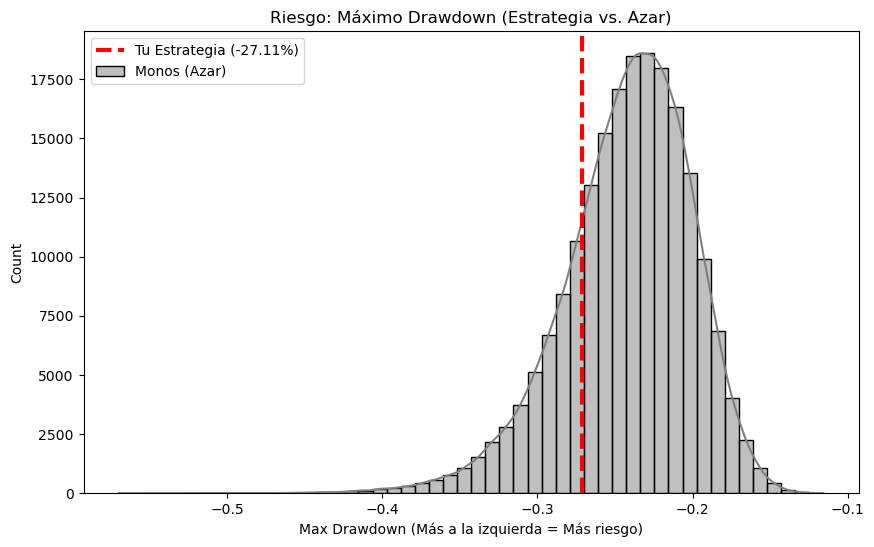

In [111]:
plt.figure(figsize=(10, 6))
sns.histplot(max_dd_monos, bins=50, color='gray', kde=True, label='Monos (Azar)')
plt.axvline(val_max_dd_est, color='red', linestyle='--', linewidth=3, label=f'Tu Estrategia ({val_max_dd_est:.2%})')
plt.title('Riesgo: Máximo Drawdown (Estrategia vs. Azar)')
plt.xlabel('Max Drawdown (Más a la izquierda = Más riesgo)')
plt.legend()
plt.show()

El siguiente boxplot muestra la rentabilidad de las simulaciones comparada con la de la estrategia momentum (marcada en rojo). Se aprecia que **la rentabilidad de la estrategia se encuentra en un percentil muy elevado** (está por encima del bigote superior).

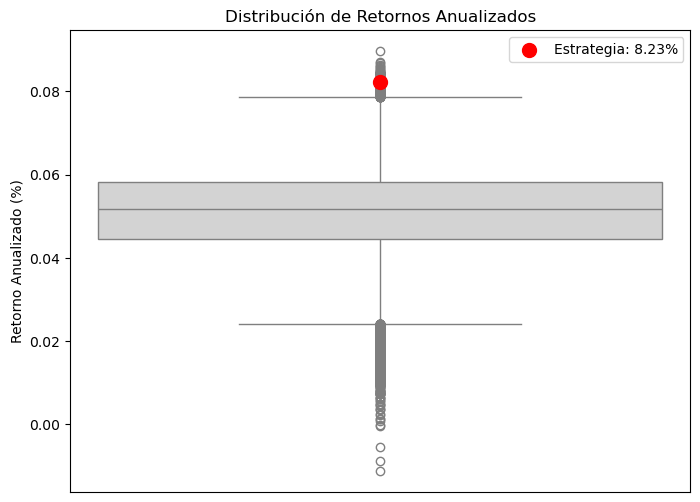

In [112]:
plt.figure(figsize=(8, 6))
sns.boxplot(data=retorno_anual_monos, color='lightgrey', showfliers=True)
plt.scatter(0, val_retorno_anual_est, color='red', s=100, zorder=5, label=f'Estrategia: {val_retorno_anual_est:.2%}')
plt.title('Distribución de Retornos Anualizados')
plt.ylabel('Retorno Anualizado (%)')
plt.xticks([]) 
plt.legend()
plt.show()

El último gráfico muestra la relación rentabilidad versus riesgo (máximo drawdown) de la estrategia (marcada con el punto rojo) comparado con el resultado de las 200.000 simulaciones.
- Se puede ver que para el nivel de la rentabilidad de la estrategia, el máximo drawdown es el menor, indicativo de que **la estrategia tiene un mayor riesgo del esperado**.
- Por otro lado, si fijamos el valor del máximo drawdown se aprecia que la **rentabilidad de la estrategia momentum es mayor que la esperada**.
- En conclusión, el resultado de la **estrategia momentum se encuentra por encima de la frontera eficiente**.

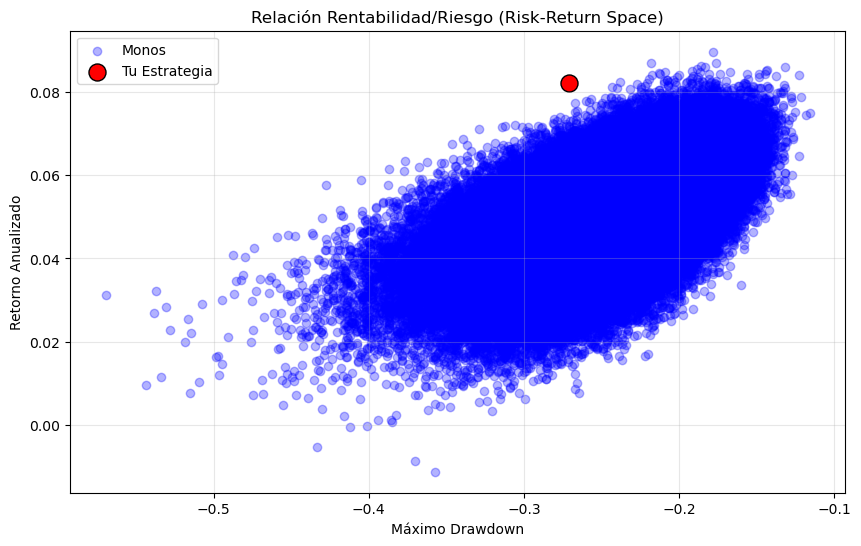

In [104]:
# Supongamos que retorno_benchmark es el retorno total del SPY en el periodo
# Si no lo tienes calculado: retorno_benchmark = 0.10 (ejemplo)

plt.figure(figsize=(10, 6))
plt.scatter(max_dd_monos, retorno_anual_monos, alpha=0.3, color='blue', label='Monos')
plt.scatter(max_dd_est, retorno_anual_est, color='red', s=150, edgecolors='black', label='Tu Estrategia')

plt.title('Relación Rentabilidad/Riesgo (Risk-Return Space)')
plt.ylabel('Retorno Anualizado')
plt.xlabel('Máximo Drawdown')
plt.grid(alpha=0.3)
plt.legend()
plt.show()

En conclusión, **la estrategia momentum es claramente superior a invertir al azar de forma consistente**.